In [1]:
# Importing necessary libraries
import os
import librosa
import numpy as np
import scipy.fftpack as fft
import matplotlib.pyplot as plt
import librosa.display
import soundfile as sf
from scipy.signal import medfilt
from matplotlib import ticker


# Spectogram range 1000 - 30000 Hz (secondary band)

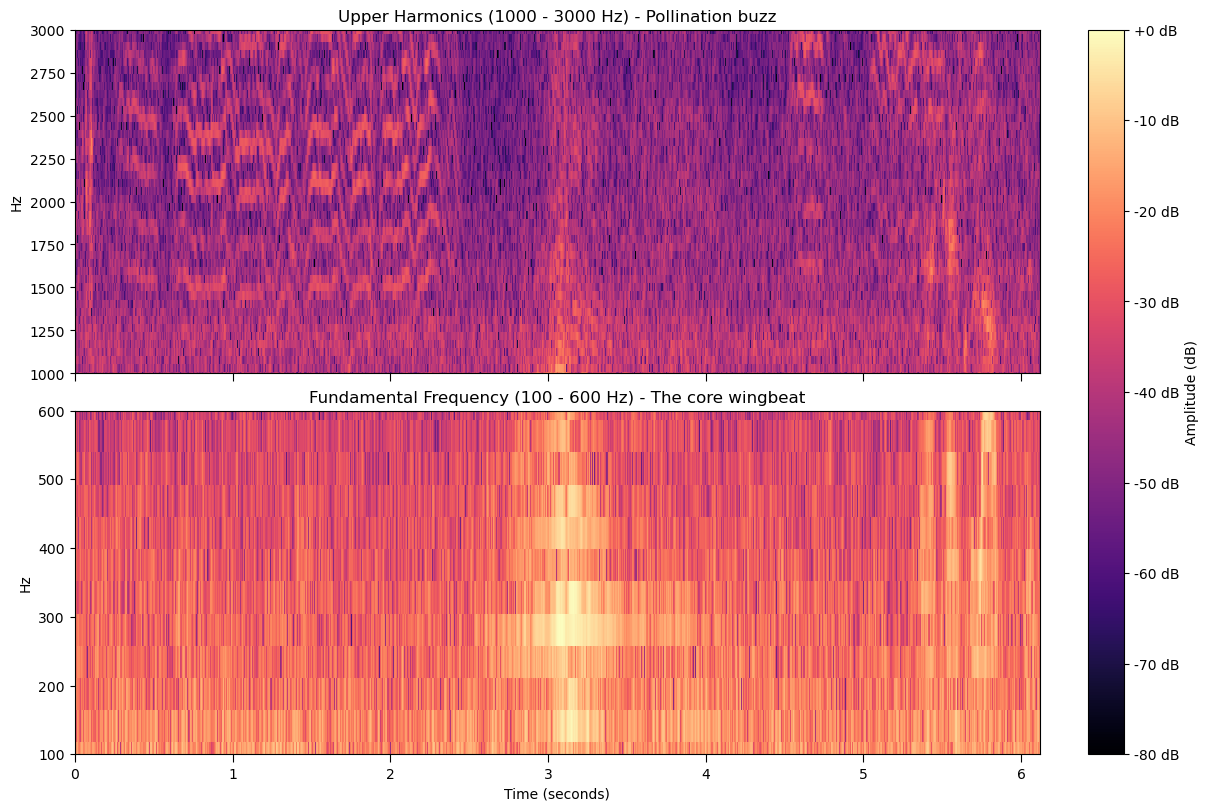

In [3]:

# Load your 4-second sliced audio file
audio_file = '../../data/audio_data/original/Bee.WAV'
y, sr = librosa.load(audio_file, sr=None)

# Compute the spectrogram
n_fft = 4096*2
hop_length = 512
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Create a figure with two subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True, constrained_layout=True)

# --- Top Plot: The Upper Harmonics (1000 - 3000 Hz) ---
img1 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', 
                                cmap='magma', n_fft=n_fft, hop_length=hop_length, ax=ax1)
ax1.set_ylim(1000, 3000)
ax1.set_title('Upper Harmonics (1000 - 3000 Hz) - Pollination buzz')
ax1.set_ylabel('Hz')
ax1.set_xlabel('') # Hide top x-label to avoid clutter

# --- Bottom Plot: The Fundamental (100 - 600 Hz) ---
img2 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', 
                                cmap='magma', n_fft=n_fft, hop_length=hop_length, ax=ax2)
ax2.set_ylim(100, 600)
ax2.set_title('Fundamental Frequency (100 - 600 Hz) - The core wingbeat')
ax2.set_ylabel('Hz')
ax2.set_xlabel("Time (seconds)")

# --- Adding the 100ms "Ruler" Timeline ---
# Set major ticks every 1 second, and minor ticks every 0.1 seconds (100 ms)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
#ax2.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# Format the ticks to look like a ruler (pointing outward, white to contrast the dark background)
#ax2.tick_params(axis='x', which='minor', length=2, color='black', direction='out')
ax2.tick_params(axis='x', which='major', length=6, color='black', direction='out')

# Apply the same ruler ticks to the top plot so they align perfectly
#ax1.tick_params(axis='x', which='minor', length=2, color='black', direction='out')
ax1.tick_params(axis='x', which='major', length=6, color='black', direction='out')

# Add a single colorbar for reference
fig.colorbar(img1, ax=[ax1, ax2], format='%+2.0f dB', label='Amplitude (dB)')

#plt.tight_layout()
plt.show()

# Your existing folder
folder = "../../results/spectrogram"

# Filename
filename = f"Spectrogram_sr={sr}_nfft={n_fft}_hop={hop_length}.png"

# Full path
file_path = os.path.join(folder, filename)

# Save figure
fig.savefig(file_path, dpi=200)

print(f"Plot saved as {file_path}")

#### The STFT Parameters (n_fft and hop_length)

To understand these two settings, it helps to think of the STFT as a video camera trying to film a fast-moving object.

\- n_fft (The Shutter Speed & Focus)
The n_fft parameter defines how many individual audio samples the algorithm grabs to calculate a single vertical slice of frequencies.

- High n_fft (e.g., 4096 or 8192): This acts like a magnifying glass for frequency. It gives you incredible Frequency Resolution. You will easily be able to tell the difference between a 150 Hz bee and a 160 Hz bee. However, because it requires analyzing a larger chunk of time to get that detail, you lose Time Resolution. A sudden, millisecond-long click will look smeared horizontally across the graph.

- Low n_fft (e.g., 512 or 1024): This gives you excellent Time Resolution. You will know the exact millisecond a sound started. But, you lose frequency detail. The entire 100 Hz to 300 Hz range might just look like one big, blurry block, making it impossible to see the bee's distinct harmonic lines.

- The Verdict for Bees: Because bumblebee fundamental frequencies are so low (120–400 Hz), you absolutely need a higher n_fft (like 4096) to see them clearly.

\- hop_length (The Framerate)
When the algorithm calculates one slice of time, it has to move forward to calculate the next slice. The hop_length is how many samples it steps forward before doing the math again.

- Low hop_length (e.g., 128 or 256): The windows heavily overlap. This is like filming at 120 frames per second. The resulting spectrogram will be incredibly smooth and visually beautiful, but it takes a lot of computing power and memory to generate.

- High hop_length (e.g., 1024 or 2048): The windows barely overlap, or don't overlap at all. The resulting image will look pixelated, blocky, and choppy, but your code will run lightning fast.

The Verdict for Bees: hop_length = 512 is usually the gold standard. It provides enough overlap for a clear image without crashing your computer's RAM.

<br>
So:

increasing the n_fft will result in a a better frequency resolution but a lower time resolution. and lower n_fft will give a high time resolution (exact miliseconds) but a (low frequency resolution.)

## Spectral subtraction code

Here constant sounds like humming and background noise will be "ignored". 

"Here is how you apply this specific mathematical fix to your spectrogram. We will use the np.median function to calculate the noise profile, because a median ignores sudden loud spikes (like the bee or your microphone bump) and finds the true "baseline" hum." 

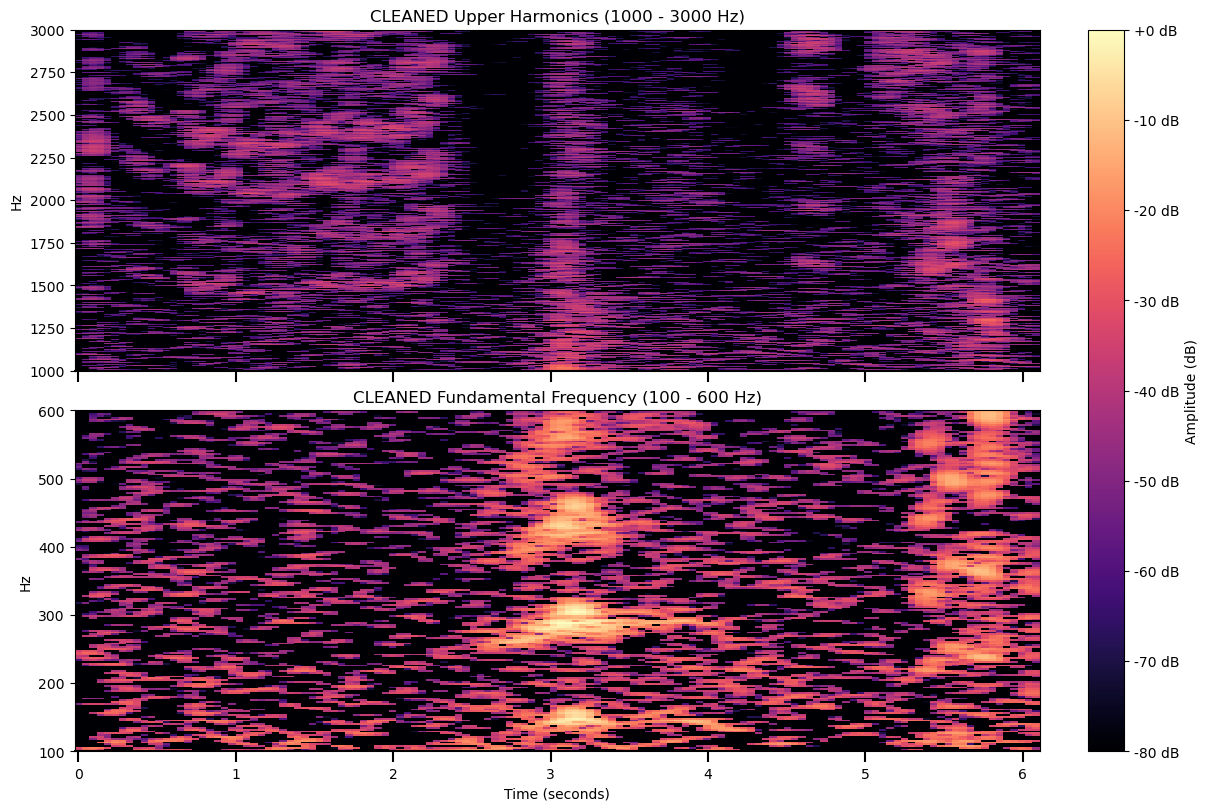

In [8]:


audio_file = '../../data/audio_data/original/Bee.WAV'
y, sr = librosa.load(audio_file, sr=11025)

# Compute the STFT
n_fft = 1024*4
hop_length = 256*2
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)

# Get the raw mathematical magnitude (not decibels yet)
magnitude = np.abs(D)

# --- SPECTRAL SUBTRACTION ---
# 1. Calculate the median energy for every single frequency row across all time
noise_profile = np.median(magnitude, axis=1, keepdims=True)

# 2. Subtract the noise profile from the original audio
# We use np.maximum(..., 0) so we don't accidentally create negative math errors
magnitude_clean = np.maximum(magnitude - noise_profile, 0)

# 3. Convert the newly cleaned audio into Decibels for plotting
S_db_clean = librosa.amplitude_to_db(magnitude_clean, ref=np.max)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True, constrained_layout=True)

# Top Plot: The Upper Harmonics
img1 = librosa.display.specshow(S_db_clean, sr=sr, x_axis='time', y_axis='hz', 
                                cmap='magma', n_fft=n_fft, hop_length=hop_length, ax=ax1)
ax1.set_ylim(1000, 3000)
ax1.set_title('CLEANED Upper Harmonics (1000 - 3000 Hz)')
ax1.set_ylabel('Hz')
ax1.set_xlabel('') 

# Bottom Plot: The Fundamental
img2 = librosa.display.specshow(S_db_clean, sr=sr, x_axis='time', y_axis='hz', 
                                cmap='magma', n_fft=n_fft, hop_length=hop_length, ax=ax2)
ax2.set_ylim(100, 600)
ax2.set_title('CLEANED Fundamental Frequency (100 - 600 Hz)')
ax2.set_ylabel('Hz')
ax2.set_xlabel('Time (seconds)')

# Formatting the Ruler
for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    #ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.tick_params(axis='x', which='major', length=8, color='black', direction='out', width=1.5)
    #ax.tick_params(axis='x', which='minor', length=4, color='black', direction='out', width=1)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)

fig.colorbar(img1, ax=[ax1, ax2], format='%+2.0f dB', label='Amplitude (dB)')


plt.show()

In [4]:
# Your existing folder
folder = "results/spectrogram"

# Filename
filename = f"Spectral_subtraction_sr={sr}_nfft={n_fft}_hop={hop_length}.png"

# Full path
file_path = os.path.join(folder, filename)

# Save figure
fig.savefig(file_path, dpi=200)

print(f"Plot saved as {file_path}")

FileNotFoundError: [Errno 2] No such file or directory: 'results/spectrogram/Spectral_subtraction_sr=11025_nfft=2048_hop=512.png'


Upper harmonic:
- Spikes at 0.5, 0.8-2.1, 3.1, 4.7, 5.1-5.8 are pollination buzzes
- Spikes lower in the screen around 1500 Hz, at time stamp 5.4, 5.6, 5.8 are voices. These ones line up with the fundemental frequency where there more clearly visible. 

Fundemental harmonics:
- It is visible that the previously saturated orange part pre 3 seconds is split into darker areas (areas that dont change qua sound)
- At time stamp 3.1 a spike is visible, this is a flight buzz. 


<br>
Note: we found that the parameters sr = 11025, n_fft=1024 and hop_length=256 for now give the best outputs. if computation takes to long. Adjust hop_length by * 2

# Peak finder

## Flight buzz

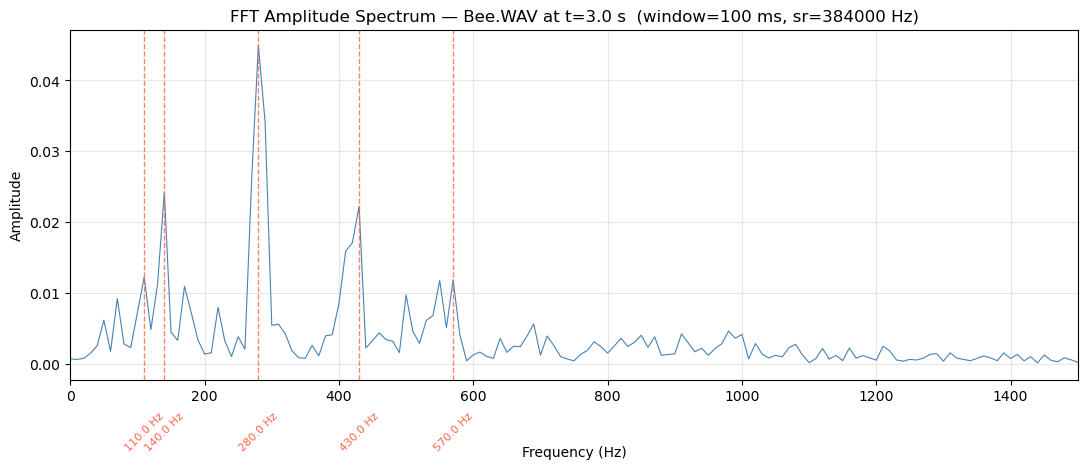

Top 5 spike(s) in 100–700 Hz (sorted by frequency):
    110.0 Hz  —  amplitude 0.012207
    140.0 Hz  —  amplitude 0.024234
    280.0 Hz  —  amplitude 0.044919
    430.0 Hz  —  amplitude 0.022204
    570.0 Hz  —  amplitude 0.011830


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load Bee.WAV at its native sample rate
audio_file = '../../data/audio_data/original/Bee3.WAV'
y, sr = librosa.load(audio_file, sr=None)

# Extract a 0.1-second window centred on t=3s
t_center   = 3.0
window_sec = 0.1
start   = int((t_center - window_sec / 2) * sr)
end     = int((t_center + window_sec / 2) * sr)
segment = y[start:end]

# FFT
N         = len(segment)
fft_vals  = np.fft.rfft(segment)
freqs     = np.fft.rfftfreq(N, d=1.0 / sr)
amplitude = np.abs(fft_vals) / N

# --- Peak detection in 100–700 Hz band ---
N_TOP_PEAKS = 5   

band_mask = (freqs >= 100) & (freqs <= 700)
band_amp  = np.where(band_mask, amplitude, 0)

peaks_idx, _ = find_peaks(
    band_amp,
    prominence=band_amp.max() * 0.05,
    distance=int(20 / (freqs[1] - freqs[0])),
)

# Keep only the top N peaks by amplitude
top_order  = np.argsort(amplitude[peaks_idx])[::-1][:N_TOP_PEAKS]
peaks_idx  = peaks_idx[top_order]
peak_freqs = freqs[peaks_idx]
peak_amps  = amplitude[peaks_idx]

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 5))
fig.subplots_adjust(bottom=0.18)   # extra space below x-axis for labels

ax.plot(freqs, amplitude, linewidth=0.8, color='steelblue')

for f, a in zip(peak_freqs, peak_amps):
    # Dashed vertical line spanning the full plot height
    ax.axvline(x=f, color='tomato', linestyle='--', linewidth=1.0, alpha=0.8)
    # Label placed just below the x-axis using axes-fraction y coordinate
    ax.annotate(
        f'{f:.1f} Hz',
        xy=(f, 0),
        xycoords=('data', 'axes fraction'),
        xytext=(0, -22),
        textcoords='offset points',
        ha='center', va='top',
        fontsize=8, color='tomato',
        rotation=45,
    )

ax.set_xlabel('Frequency (Hz)', labelpad=30)
ax.set_ylabel('Amplitude')
ax.set_title(f'FFT Amplitude Spectrum — Bee.WAV at t={t_center} s  '
             f'(window={window_sec*1000:.0f} ms, sr={sr} Hz)')
ax.set_xlim(0, min(1500, sr / 2))
ax.grid(True, alpha=0.3)
plt.show()

print(f"Top {N_TOP_PEAKS} spike(s) in 100–700 Hz (sorted by frequency):")
for f, a in sorted(zip(peak_freqs, peak_amps)):
    print(f"  {f:7.1f} Hz  —  amplitude {a:.6f}")


Top 5 peaks in 100–700 Hz  [Bee.WAV  t=3.0s]:
    110.0 Hz  —  amplitude 0.012207
    140.0 Hz  —  amplitude 0.024234
    280.0 Hz  —  amplitude 0.044919
    430.0 Hz  —  amplitude 0.022204
    570.0 Hz  —  amplitude 0.011830

Top 5 peaks in 100–700 Hz  [Bee3.WAV  t=3.0s]:
    110.0 Hz  —  amplitude 0.012237
    240.0 Hz  —  amplitude 0.007231
    420.0 Hz  —  amplitude 0.005211
    640.0 Hz  —  amplitude 0.005913
    690.0 Hz  —  amplitude 0.004991


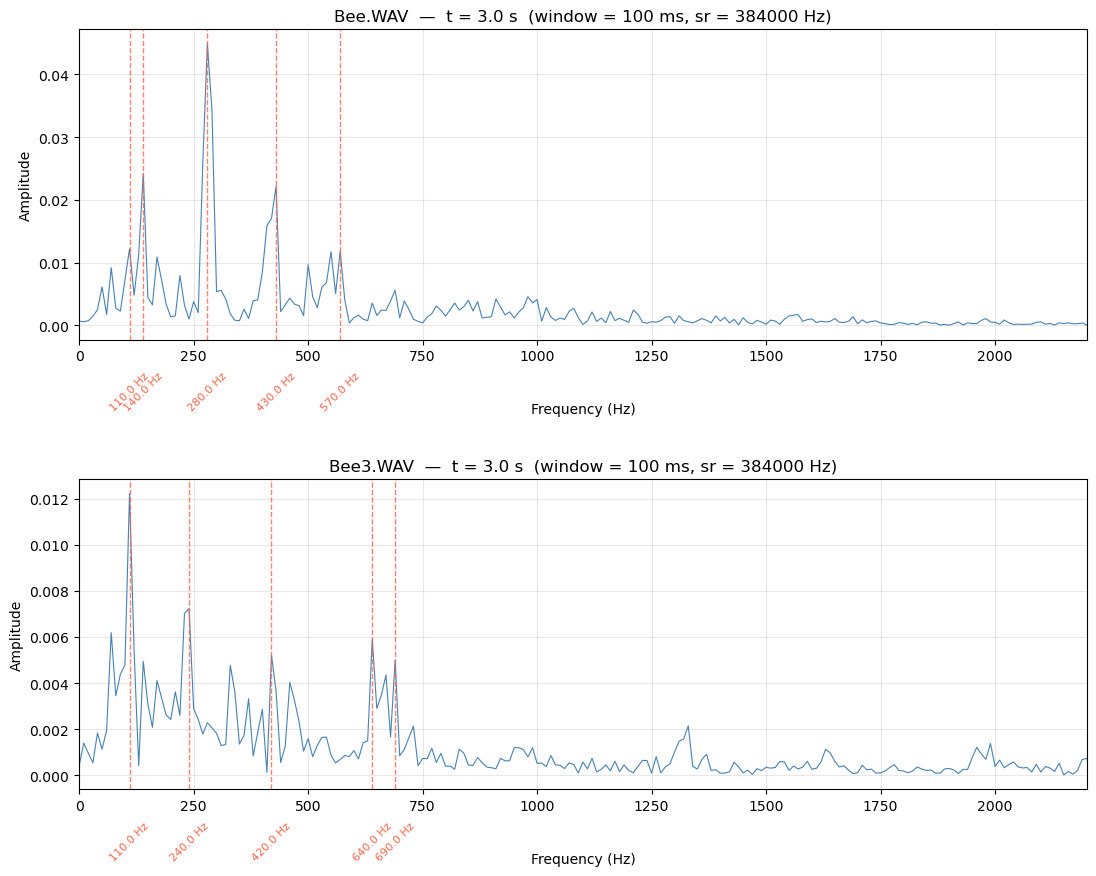

In [10]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Settings ---
FILES = [
    ('../../data/audio_data/original/Bee.WAV',  3.0),
    ('../../data/audio_data/original/Bee3.WAV', 3.0),
]
WINDOW_SEC  = 0.1
N_TOP_PEAKS = 5      # ← number of peaks to highlight per plot
FREQ_LOW    = 100    # ← lower bound of peak detection (Hz)
FREQ_HIGH   = 700    # ← upper bound of peak detection (Hz)
PLOT_XLIM   = 2200   # ← right edge of x-axis (Hz)

def compute_fft(audio_file, t_center, window_sec):
    y, sr = librosa.load(audio_file, sr=None)
    start   = int((t_center - window_sec / 2) * sr)
    end     = int((t_center + window_sec / 2) * sr)
    segment = y[start:end]
    N         = len(segment)
    fft_vals  = np.fft.rfft(segment)
    freqs     = np.fft.rfftfreq(N, d=1.0 / sr)
    amplitude = np.abs(fft_vals) / N
    return freqs, amplitude, sr

def detect_peaks(freqs, amplitude, freq_low, freq_high, n_top):
    band_mask = (freqs >= freq_low) & (freqs <= freq_high)
    band_amp  = np.where(band_mask, amplitude, 0)
    peaks_idx, _ = find_peaks(
        band_amp,
        prominence=band_amp.max() * 0.05,
        distance=int(20 / (freqs[1] - freqs[0])),
    )
    top_order = np.argsort(amplitude[peaks_idx])[::-1][:n_top]
    peaks_idx = peaks_idx[top_order]
    return freqs[peaks_idx], amplitude[peaks_idx]

# --- Plot ---
fig, axes = plt.subplots(nrows=len(FILES), ncols=1, figsize=(13, 5 * len(FILES)))
fig.subplots_adjust(hspace=0.45, bottom=0.12)

for ax, (audio_file, t_center) in zip(axes, FILES):
    freqs, amplitude, sr = compute_fft(audio_file, t_center, WINDOW_SEC)
    peak_freqs, peak_amps = detect_peaks(freqs, amplitude, FREQ_LOW, FREQ_HIGH, N_TOP_PEAKS)

    label = audio_file.split('/')[-1]
    ax.plot(freqs, amplitude, linewidth=0.8, color='steelblue')

    for f, a in zip(peak_freqs, peak_amps):
        ax.axvline(x=f, color='tomato', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.annotate(
            f'{f:.1f} Hz',
            xy=(f, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -22), textcoords='offset points',
            ha='center', va='top', fontsize=8, color='tomato', rotation=45,
        )

    ax.set_title(f'{label}  —  t = {t_center} s  (window = {WINDOW_SEC*1000:.0f} ms, sr = {sr} Hz)')
    ax.set_xlabel('Frequency (Hz)', labelpad=28)
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, min(PLOT_XLIM, sr / 2))
    ax.grid(True, alpha=0.3)

    print(f"\nTop {N_TOP_PEAKS} peaks in {FREQ_LOW}–{FREQ_HIGH} Hz  [{label}  t={t_center}s]:")
    for f, a in sorted(zip(peak_freqs, peak_amps)):
        print(f"  {f:7.1f} Hz  —  amplitude {a:.6f}")

plt.show()

### Radio

at t=45 somewhat normal background, voices/radio
at t=5 a lot of white noise


Top 5 peaks in 100–700 Hz  [20260324_130200.WAV  t=5.0s]:
    160.0 Hz  —  amplitude 0.012223
    180.0 Hz  —  amplitude 0.008359
    240.0 Hz  —  amplitude 0.007146
    310.0 Hz  —  amplitude 0.010585
    470.0 Hz  —  amplitude 0.007703

Top 5 peaks in 100–700 Hz  [20260324_130200.WAV  t=45.0s]:
    100.0 Hz  —  amplitude 0.018993
    420.0 Hz  —  amplitude 0.004883
    460.0 Hz  —  amplitude 0.004538
    520.0 Hz  —  amplitude 0.004863
    570.0 Hz  —  amplitude 0.009027


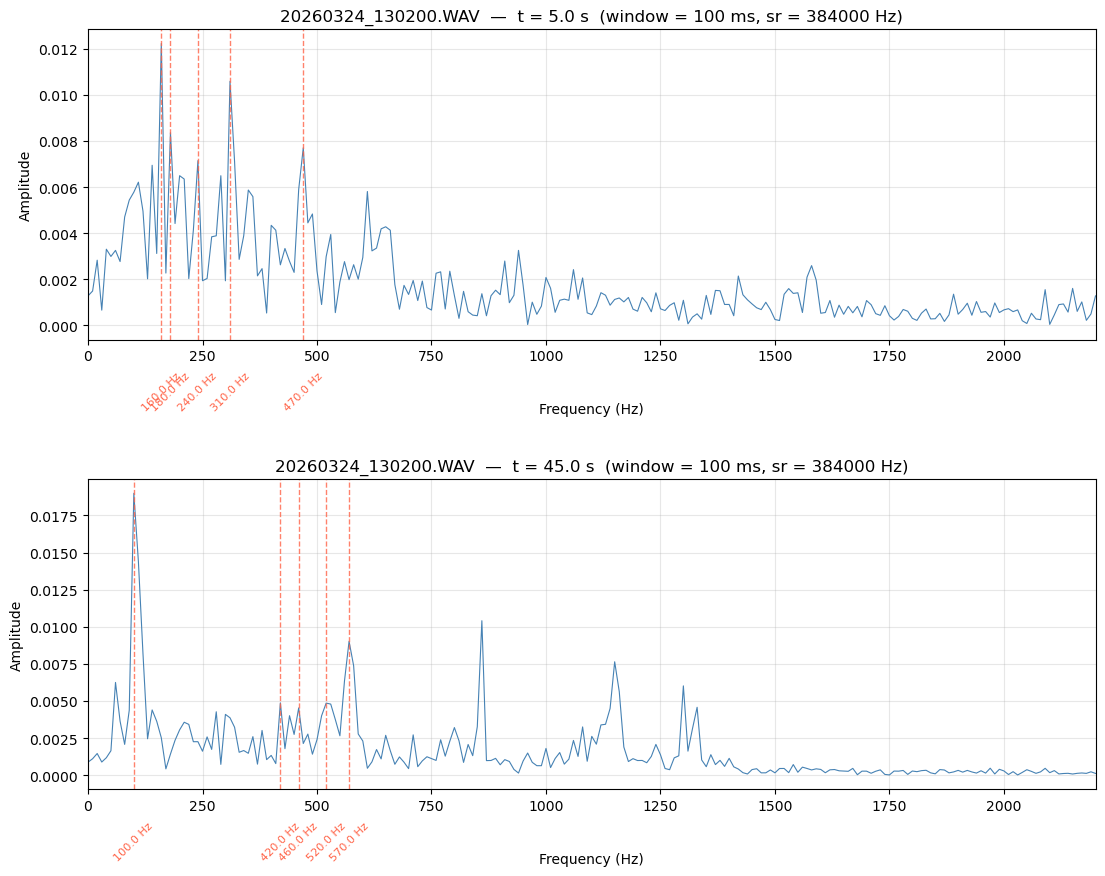

In [11]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Settings ---
FILES = [
    ('../../data/audio_data/original/20260324_130200.WAV',  5.0),
    ('../../data/audio_data/original/20260324_130200.WAV',  45.0)
]
WINDOW_SEC  = 0.1
N_TOP_PEAKS = 5      # ← number of peaks to highlight per plot
FREQ_LOW    = 100    # ← lower bound of peak detection (Hz)
FREQ_HIGH   = 700    # ← upper bound of peak detection (Hz)
PLOT_XLIM   = 2200   # ← right edge of x-axis (Hz)

def compute_fft(audio_file, t_center, window_sec):
    y, sr = librosa.load(audio_file, sr=None)
    start   = int((t_center - window_sec / 2) * sr)
    end     = int((t_center + window_sec / 2) * sr)
    segment = y[start:end]
    N         = len(segment)
    fft_vals  = np.fft.rfft(segment)
    freqs     = np.fft.rfftfreq(N, d=1.0 / sr)
    amplitude = np.abs(fft_vals) / N
    return freqs, amplitude, sr

def detect_peaks(freqs, amplitude, freq_low, freq_high, n_top):
    band_mask = (freqs >= freq_low) & (freqs <= freq_high)
    band_amp  = np.where(band_mask, amplitude, 0)
    peaks_idx, _ = find_peaks(
        band_amp,
        prominence=band_amp.max() * 0.05,
        distance=int(20 / (freqs[1] - freqs[0])),
    )
    top_order = np.argsort(amplitude[peaks_idx])[::-1][:n_top]
    peaks_idx = peaks_idx[top_order]
    return freqs[peaks_idx], amplitude[peaks_idx]

# --- Plot ---
fig, axes = plt.subplots(nrows=len(FILES), ncols=1, figsize=(13, 5 * len(FILES)))
fig.subplots_adjust(hspace=0.45, bottom=0.12)

for ax, (audio_file, t_center) in zip(axes, FILES):
    freqs, amplitude, sr = compute_fft(audio_file, t_center, WINDOW_SEC)
    peak_freqs, peak_amps = detect_peaks(freqs, amplitude, FREQ_LOW, FREQ_HIGH, N_TOP_PEAKS)

    label = audio_file.split('/')[-1]
    ax.plot(freqs, amplitude, linewidth=0.8, color='steelblue')

    for f, a in zip(peak_freqs, peak_amps):
        ax.axvline(x=f, color='tomato', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.annotate(
            f'{f:.1f} Hz',
            xy=(f, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -22), textcoords='offset points',
            ha='center', va='top', fontsize=8, color='tomato', rotation=45,
        )

    ax.set_title(f'{label}  —  t = {t_center} s  (window = {WINDOW_SEC*1000:.0f} ms, sr = {sr} Hz)')
    ax.set_xlabel('Frequency (Hz)', labelpad=28)
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, min(PLOT_XLIM, sr / 2))
    ax.grid(True, alpha=0.3)

    print(f"\nTop {N_TOP_PEAKS} peaks in {FREQ_LOW}–{FREQ_HIGH} Hz  [{label}  t={t_center}s]:")
    for f, a in sorted(zip(peak_freqs, peak_amps)):
        print(f"  {f:7.1f} Hz  —  amplitude {a:.6f}")

plt.show()

## Buzz pollination

### 6 plots overview
 
 using bee3.WAV file to look at half a second increments. At t=3 the frist pollination buzz is heard


'Top 5 peaks in 1000–2500 Hz  [Bee3.WAV  t=2.5s]:'

   1220.0 Hz  —  amplitude 0.001654
   1320.0 Hz  —  amplitude 0.001218
   1340.0 Hz  —  amplitude 0.001453
   1520.0 Hz  —  amplitude 0.001416
   1610.0 Hz  —  amplitude 0.001213


'Top 5 peaks in 1000–2500 Hz  [Bee3.WAV  t=3.0s]:'

   1330.0 Hz  —  amplitude 0.002142
   1630.0 Hz  —  amplitude 0.001130
   1960.0 Hz  —  amplitude 0.001213
   1990.0 Hz  —  amplitude 0.001378
   2380.0 Hz  —  amplitude 0.001078


'Top 5 peaks in 1000–2500 Hz  [Bee3.WAV  t=3.5s]:'

...

   1170.0 Hz  —  amplitude 0.002860
   1210.0 Hz  —  amplitude 0.002174
   1460.0 Hz  —  amplitude 0.002690
   1820.0 Hz  —  amplitude 0.001730
   1940.0 Hz  —  amplitude 0.002339


'Top 5 peaks in 1000–2500 Hz  [Bee3.WAV  t=4.5s]:'

   1030.0 Hz  —  amplitude 0.001399
   1270.0 Hz  —  amplitude 0.001436
   1580.0 Hz  —  amplitude 0.001758
   1630.0 Hz  —  amplitude 0.001218
   1690.0 Hz  —  amplitude 0.001393


'Top 5 peaks in 1000–2500 Hz  [Bee3.WAV  t=5.0s]:'

   1160.0 Hz  —  amplitude 0.001835
   1250.0 Hz  —  amplitude 0.002330
   1290.0 Hz  —  amplitude 0.001499
   1650.0 Hz  —  amplitude 0.002460
   1730.0 Hz  —  amplitude 0.002191


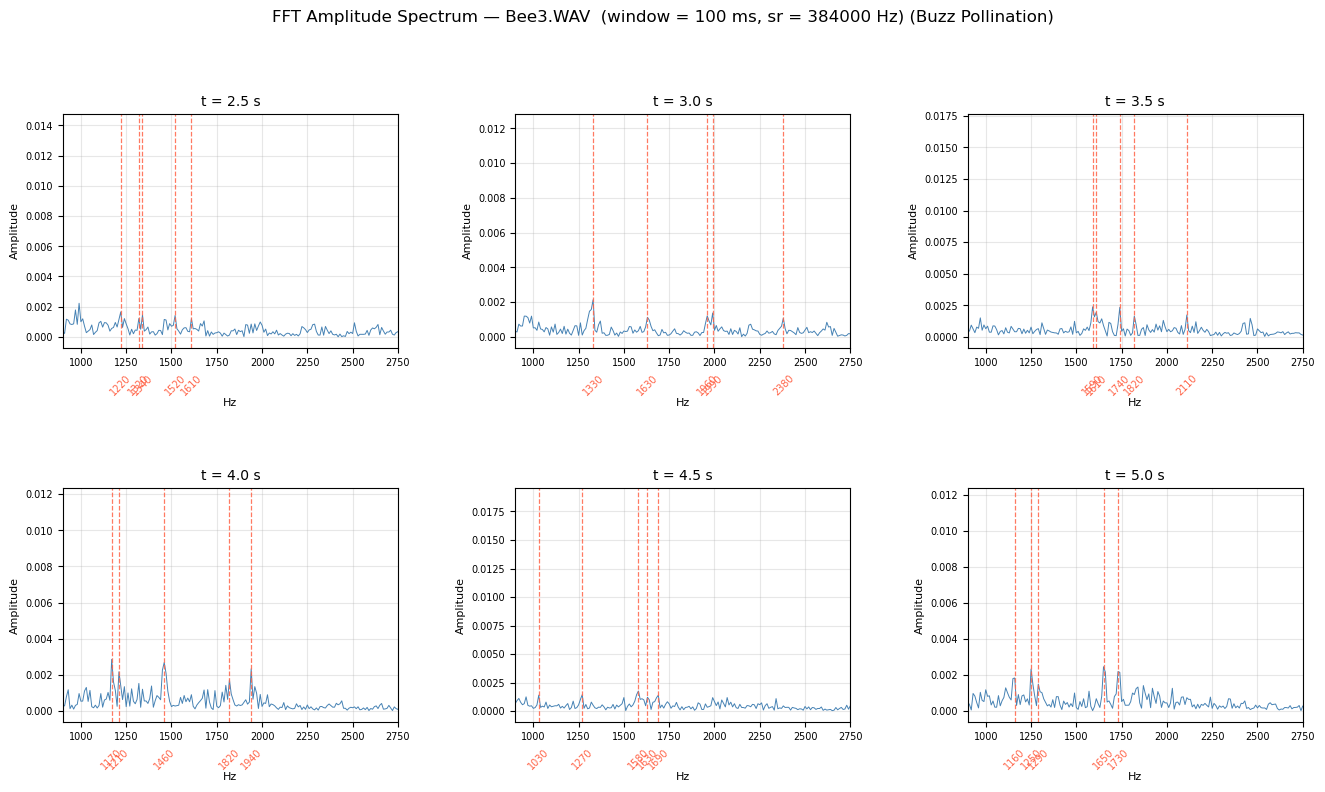

In [8]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Settings ---
AUDIO_FILE  = '../../data/audio_data/original/Bee3.WAV'
TIMESTAMPS  = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]   # ← moments to inspect (seconds)
WINDOW_SEC  = 0.1    # window size around each timestamp
N_TOP_PEAKS = 5      # ← peaks to highlight per plot
FREQ_LOW    = 1000    # ← peak detection range (Hz)
FREQ_HIGH   = 2500
PLOT_XLIM   = 3000   # ← right edge of x-axis (Hz)

# Load once
y, sr = librosa.load(AUDIO_FILE, sr=None)
label = AUDIO_FILE.split('/')[-1]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
fig.suptitle(f'FFT Amplitude Spectrum — {label}  (window = {WINDOW_SEC*1000:.0f} ms, sr = {sr} Hz) (Buzz Pollination)',
             fontsize=12, y=1.01)
fig.subplots_adjust(hspace=0.6, wspace=0.35, bottom=0.12)

for ax, t_center in zip(axes.flat, TIMESTAMPS):
    # Extract window
    start   = int((t_center - WINDOW_SEC / 2) * sr)
    end     = int((t_center + WINDOW_SEC / 2) * sr)
    segment = y[start:end]

    # FFT
    N         = len(segment)
    fft_vals  = np.fft.rfft(segment)
    freqs     = np.fft.rfftfreq(N, d=1.0 / sr)
    amplitude = np.abs(fft_vals) / N

    # Peak detection in band
    band_mask = (freqs >= FREQ_LOW) & (freqs <= FREQ_HIGH)
    band_amp  = np.where(band_mask, amplitude, 0)
    peaks_idx, _ = find_peaks(
        band_amp,
        prominence=band_amp.max() * 0.05,
        distance=int(20 / (freqs[1] - freqs[0])),
    )
    top_order  = np.argsort(amplitude[peaks_idx])[::-1][:N_TOP_PEAKS]
    peaks_idx  = peaks_idx[top_order]
    peak_freqs = freqs[peaks_idx]
    peak_amps  = amplitude[peaks_idx]

    # Plot spectrum
    ax.plot(freqs, amplitude, linewidth=0.7, color='steelblue')

    for f, a in zip(peak_freqs, peak_amps):
        ax.axvline(x=f, color='tomato', linestyle='--', linewidth=0.9, alpha=0.85)
        ax.annotate(
            f'{f:.0f}',
            xy=(f, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -18), textcoords='offset points',
            ha='center', va='top', fontsize=7, color='tomato', rotation=45,
        )

    ax.set_title(f't = {t_center} s', fontsize=10)
    ax.set_xlabel('Hz', labelpad=22, fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.set_xlim(900, 2750)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

    display(f"Top {N_TOP_PEAKS} peaks in {FREQ_LOW}–{FREQ_HIGH} Hz  [{label}  t={t_center}s]:")
    for f, a in sorted(zip(peak_freqs, peak_amps)):
        print(f"  {f:7.1f} Hz  —  amplitude {a:.6f}")

plt.show()

pollination buzz begins at t=3 seconds, loudest at t=4 and t=5. 

# First harmonic frequency (Flight)


In [46]:
# Load the audio file
audio_file = '20260324_111301.WAV'
y, sr = librosa.load(audio_file, sr=None)  # sr=None to keep original sample rate

# Define the frequency band to keep (in Hz) - single band
low, high = 140, 500

# Compute FFT
Y = fft.fft(y)
freqs = fft.fftfreq(len(y), 1/sr)

# Create mask for the desired band
mask = np.zeros_like(Y, dtype=complex)
mask[(freqs >= low) & (freqs <= high)] = 1
mask[(freqs >= -high) & (freqs <= -low)] = 1  # for negative frequencies

# Apply the mask
Y_filtered = Y * mask

# Inverse FFT to get filtered signal
y_filtered = fft.ifft(Y_filtered).real

# Normalize to prevent clipping (optional, depending on the signal)
y_filtered = y_filtered / np.max(np.abs(y_filtered)) * 0.9

# Save the filtered audio
sf.write('filtered_single_band4.wav', y_filtered, sr)

print("Filtered audio saved as 'filtered_single_band4.wav'")

Filtered audio saved as 'filtered_single_band4.wav'


### Conclusion

In both the range 120 - 400 linked to "Filtered_single_band3.wav" and 120-500 linked to "Filtered_single_band4.wav" the flight buzz can be heard. Below a spectogram of both files will be made and analysed to determine the best frequency range. 

# Second harmonic frequency (pollination)

Precise frequency range is to be determined for the foraging traits. This is estimated to be 3 to 5 times as high as flight buzzes. In this section multiple bands are tested to narrow down the frequency range and reduce the background noise.  

## Filter 2

In [6]:
# Load the audio file
audio_file = '20260324_111301.WAV'
y, sr = librosa.load(audio_file, sr=None)  # sr=None to keep original sample rate

# Define the frequency band to keep (in Hz) - single band
low, high = 1000, 5000

# Compute FFT
Y = fft.fft(y)
freqs = fft.fftfreq(len(y), 1/sr)

# Create mask for the desired band
mask = np.zeros_like(Y, dtype=complex)
mask[(freqs >= low) & (freqs <= high)] = 1
mask[(freqs >= -high) & (freqs <= -low)] = 1  # for negative frequencies

# Apply the mask
Y_filtered = Y * mask

# Inverse FFT to get filtered signal
y_filtered = fft.ifft(Y_filtered).real

# Normalize to prevent clipping (optional, depending on the signal)
y_filtered = y_filtered / np.max(np.abs(y_filtered)) * 0.9


# Save the filtered audio
sf.write('filtered_high_band_2.wav', y_filtered, sr)

print("Filtered audio saved as 'filtered_high_band_2.wav'")

Filtered audio saved as 'filtered_high_band_2.wav'


## Filter 3

In [27]:
# Load the audio file
audio_file = '20260324_111301.WAV'
y, sr = librosa.load(audio_file, sr=None)  # sr=None to keep original sample rate

# Define the frequency bands to keep (in Hz)
bands = [(140, 500), (5000, 25000)] # Lower frequency is related to fundemental frequency (flight), Higher frequencie is linked to the buzz pollination

# Compute FFT
Y = fft.fft(y)
freqs = fft.fftfreq(len(y), 1/sr)

# Create mask for the desired bands
mask = np.zeros_like(Y, dtype=complex)
for low, high in bands:
    mask[(freqs >= low) & (freqs <= high)] = 1
    mask[(freqs >= -high) & (freqs <= -low)] = 1  # for negative frequencies

# Apply the mask
Y_filtered = Y * mask

# Inverse FFT to get filtered signal
y_filtered = fft.ifft(Y_filtered).real

# Normalize to prevent clipping (optional, depending on the signal)
y_filtered = y_filtered / np.max(np.abs(y_filtered)) * 0.9

# Save the filtered audio
sf.write('filtered_multi_band_3.wav', y_filtered, sr)

print("Filtered audio saved as 'filtered_multi_band_3.wav'")

In [8]:
# Load the audio file
audio_file = '20260324_111301.WAV'
y, sr = librosa.load(audio_file, sr=None)  # sr=None to keep original sample rate

# Define the frequency band to keep (in Hz) - single band
low, high = 1000, 3000

# Compute FFT
Y = fft.fft(y)
freqs = fft.fftfreq(len(y), 1/sr)

# Create mask for the desired band
mask = np.zeros_like(Y, dtype=complex)
mask[(freqs >= low) & (freqs <= high)] = 1
mask[(freqs >= -high) & (freqs <= -low)] = 1  # for negative frequencies

# Apply the mask
Y_filtered = Y * mask

# Inverse FFT to get filtered signal
y_filtered = fft.ifft(Y_filtered).real

# Normalize to prevent clipping (optional, depending on the signal)
y_filtered = y_filtered / np.max(np.abs(y_filtered)) * 0.9


# Save the filtered audio
sf.write('filtered_high_band_3.wav', y_filtered, sr)

print("Filtered audio saved as 'filtered_high_band_3.wav'")

Filtered audio saved as 'filtered_high_band_3.wav'


## Filter 4

In [30]:
# Load the audio file
audio_file = '20260324_111301.WAV'
y, sr = librosa.load(audio_file, sr=None)  # sr=None to keep original sample rate

# Define the frequency bands to keep (in Hz)
bands = [(140, 500), (2000, 3000), (5000, 6000)]

# Compute FFT
Y = fft.fft(y)
freqs = fft.fftfreq(len(y), 1/sr)

# Create mask for the desired bands
mask = np.zeros_like(Y, dtype=complex)
for low, high in bands:
    mask[(freqs >= low) & (freqs <= high)] = 1
    mask[(freqs >= -high) & (freqs <= -low)] = 1  # for negative frequencies

# Apply the mask
Y_filtered = Y * mask

# Inverse FFT to get filtered signal
y_filtered = fft.ifft(Y_filtered).real

# Normalize to prevent clipping (optional, depending on the signal)
y_filtered = y_filtered / np.max(np.abs(y_filtered)) * 0.9

# Save the filtered audio
sf.write('filtered_multi_band_4.wav', y_filtered, sr)

print("Filtered audio saved as 'filtered_multi_band_4.wav'")

Filtered audio saved as 'filtered_multi_band_4.wav'


## Filter 5

In [28]:
# Load the audio file
audio_file = '20260324_111301.WAV'
y, sr = librosa.load(audio_file, sr=None)  # sr=None to keep original sample rate

# Define the frequency bands to keep (in Hz)
bands = [(140, 500), (2000, 3000)] # Lower frequency is related to fundemental frequency (flight), Higher frequencie is linked to the buzz pollination

# Compute FFT
Y = fft.fft(y)
freqs = fft.fftfreq(len(y), 1/sr)

# Create mask for the desired bands
mask = np.zeros_like(Y, dtype=complex)
for low, high in bands:
    mask[(freqs >= low) & (freqs <= high)] = 1
    mask[(freqs >= -high) & (freqs <= -low)] = 1  # for negative frequencies

# Apply the mask
Y_filtered = Y * mask

# Inverse FFT to get filtered signal
y_filtered = fft.ifft(Y_filtered).real

# Normalize to prevent clipping (optional, depending on the signal)
y_filtered = y_filtered / np.max(np.abs(y_filtered)) * 0.9

# Save the filtered audio
sf.write('filtered_multi_band_5.wav', y_filtered, sr)

print("Filtered audio saved as 'filtered_multi_band_5.wav'")

Filtered audio saved as 'filtered_multi_band_5.wav'


# Aggregate spectrogram analysis